<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/SVM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [46]:
import numpy as np

data = np.load(PROCESSED_DIR + "/channe14_LOS_cluster1.npy")

print(data.shape)

(8140, 72)


In [47]:
import numpy as np
import os

files = [
    "channe14_LOS_cluster1.npy",
    "channe14_LOS_cluster2.npy",
    "channe14_LOS_cluster3.npy",
    "channe14_LOS_cluster4.npy",
    "channe14_NLOS_cluster1.npy",
    "channe14_NLOS_cluster2.npy",
    "channe14_NLOS_cluster3.npy",
    "channe14_NLOS_cluster4.npy",
    "channe14_NLOS_cluster5.npy"
]

env_data = []
env_labels = []
env_names = []

In [48]:
train_files = [
    "channe14_LOS_cluster1.npy",
    "channe14_LOS_cluster2.npy",
    "channe14_NLOS_cluster1.npy",
    "channe14_NLOS_cluster2.npy",
    "channe14_NLOS_cluster3.npy"
]

test_files = [
    "channe14_LOS_cluster3.npy",
    "channe14_LOS_cluster4.npy",
    "channe14_NLOS_cluster4.npy",
    "channe14_NLOS_cluster5.npy"
]

In [49]:
import numpy as np
import os

def load_data(file_list):
    X_list = []
    y_list = []

    for file in file_list:
        X = np.load(os.path.join(PROCESSED_DIR, file))

        # Assign labels
        if "NLOS" in file:
            y = np.ones(X.shape[0])
        else:
            y = np.zeros(X.shape[0])

        X_list.append(X)
        y_list.append(y)

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    return X, y

In [50]:
X_train, y_train = load_data(train_files)
X_test, y_test = load_data(test_files)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (30492, 72)
Test shape: (24333, 72)


In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8225866107754901


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.73      0.85     16213
         1.0       0.65      1.00      0.79      8120

    accuracy                           0.82     24333
   macro avg       0.83      0.87      0.82     24333
weighted avg       0.88      0.82      0.83     24333



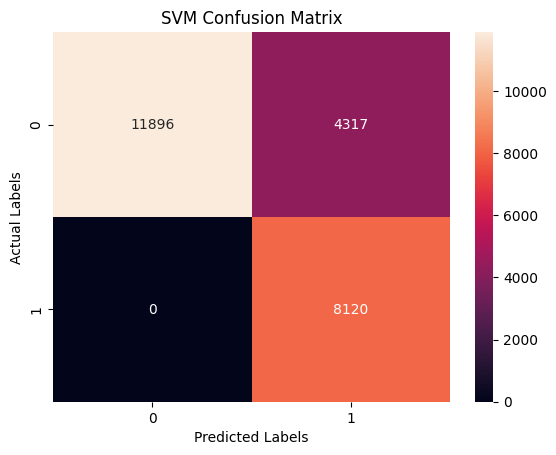

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.show()

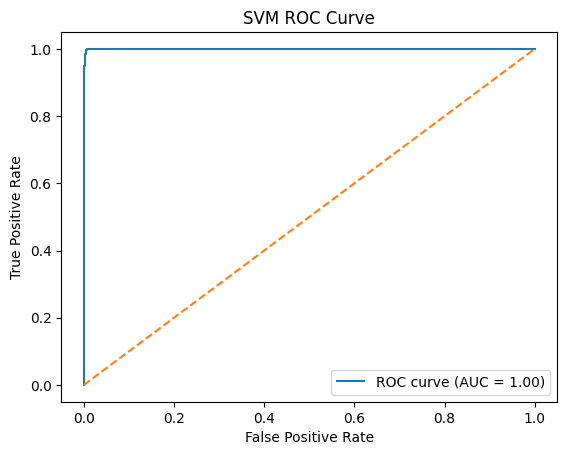

In [54]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()

plt.show()

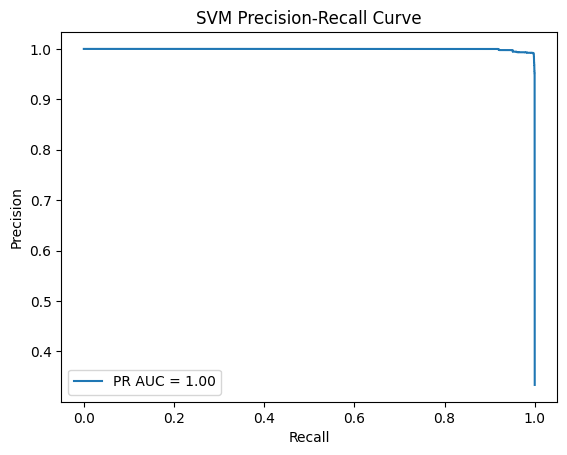

In [55]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM Precision-Recall Curve")
plt.legend()

plt.show()

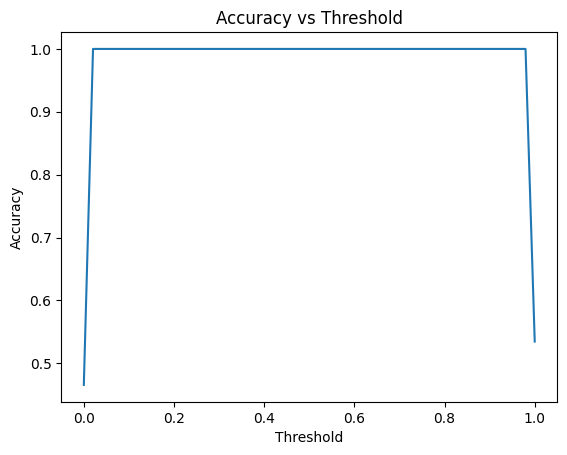

In [56]:
plt.figure()
plt.plot(thresholds, accs)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


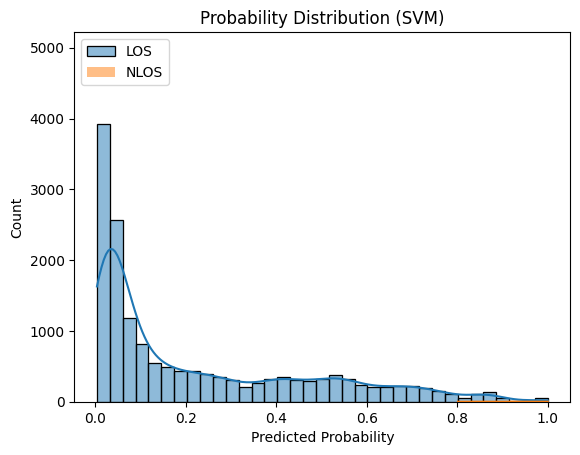

In [57]:
import seaborn as sns

plt.figure()
sns.histplot(y_test_prob[y_test == 0], label="LOS", kde=True)
sns.histplot(y_test_prob[y_test == 1], label="NLOS", kde=True)

plt.xlabel("Predicted Probability")
plt.title("Probability Distribution (SVM)")
plt.legend()

plt.show()

------------------------------------

In [33]:
print(y_prob[:20])
print(y_pred[:20])
print(y_test[:20])

[0.98769761 0.98770587 0.98770912 0.9877093  0.98771059 0.98771415
 0.98770995 0.9877114  0.98771536 0.98771452 0.98771366 0.98771627
 0.98771743 0.98771639 0.98771704 0.98771988 0.98771695 0.98771649
 0.9877172  0.98771839]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [34]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.linspace(0, 1, 50)
accs = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    accs.append(accuracy_score(y_test, y_pred_t))

print("Best accuracy:", max(accs))

Best accuracy: 0.9962602227427773


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (24393, 72)
Validation: (6099, 72)


In [43]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [44]:
from sklearn.metrics import accuracy_score

y_val_prob = model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0, 1, 50)
accs = []

for t in thresholds:
    y_pred_val = (y_val_prob >= t).astype(int)
    accs.append(accuracy_score(y_val, y_pred_val))

best_threshold = thresholds[np.argmax(accs)]

print("Best Threshold:", best_threshold)
print("Best Validation Accuracy:", max(accs))

Best Threshold: 0.02040816326530612
Best Validation Accuracy: 1.0


In [45]:
y_test_prob = model.predict_proba(X_test)[:, 1]

# Default prediction
y_test_pred_default = model.predict(X_test)

# Optimized threshold prediction
y_test_pred_opt = (y_test_prob >= best_threshold).astype(int)

print("Test Accuracy (default):", accuracy_score(y_test, y_test_pred_default))
print("Test Accuracy (optimized):", accuracy_score(y_test, y_test_pred_opt))

Test Accuracy (default): 0.8182714831710023
Test Accuracy (optimized): 0.4346360909053549
